In [1]:
# ==============================================================================
# NOTEBOOK 03: PIPELINE C - 1D-CNN+GRU SU VETTORI DI FEATURE
# ==============================================================================
# OBIETTIVO:
# Addestrare e valutare un modello 1D-CNN+GRU utilizzando un vettore combinato
# di feature audio (centroid, rolloff, zcr, chroma, contrast).
# Questo approccio è alternativo a quello basato su spettrogrammi 2D.
# ==============================================================================

# --- 1. SETUP E CONFIGURAZIONE (CORRETTO PER GOOGLE COLAB) ---
print("--- [FASE 1/6] SETUP E CONFIGURAZIONE ---")

import os
import sys
import json
import glob
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from google.colab import drive

import tensorflow as tf
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

# 1. Monta Google Drive
drive.mount('/content/drive', force_remount=True)

# 2. Definisci il percorso radice del progetto e aggiungilo al path di sistema
#    Questo blocco cerca un percorso valido per permettere la collaborazione.
known_paths = [
    '/content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab', # Esempio percorso 1
    '/content/drive/MyDrive/Colab/urbanSmartSound_Colab'   # Esempio percorso 2
]
PROJECT_ROOT = None
for path in known_paths:
    if os.path.exists(path):
        PROJECT_ROOT = path
        break

if not PROJECT_ROOT:
    raise FileNotFoundError("ERRORE: Nessuno dei percorsi di progetto conosciuti è stato trovato. Aggiorna 'known_paths' con il tuo percorso.")

print(f"Cartella di progetto trovata a: {PROJECT_ROOT}")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# 3. Importa i moduli custom dal progetto
from src import data_loader, models, evaluation

# 4. Configurazione specifica della pipeline
PIPELINE_NAME = "Pipeline_C_Vector"
FEATURE_LOADER_FN = data_loader.load_vector_features  # Usa la funzione per caricare vettori 1D
MODEL_CREATOR_FN = models.create_advanced_1d_cnn_2gru_model     # Usa il modello 1D corrispondente
MODEL_FILENAME = "model_C_vector.keras"
METADATA_FILENAME = "model_C_vector_metadata.json"

# 5. Definizione dei percorsi assoluti per dati e modelli
FEATURES_DIR = os.path.join(PROJECT_ROOT, "data/processed/features_v2")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
CSV_PATH = os.path.join(PROJECT_ROOT, "data/raw/UrbanSound8K.csv")
os.makedirs(MODELS_DIR, exist_ok=True)

print("\nConfigurazione completata:")
print(f"  - Pipeline: {PIPELINE_NAME}")
print(f"  - Funzione di caricamento: {FEATURE_LOADER_FN.__name__}")
print(f"  - Funzione di creazione modello: {MODEL_CREATOR_FN.__name__}")


# --- 2. CARICAMENTO DATI ---
print("\n[Fase 1/5] Caricamento di tutti i dati (Feature Vector)...")
all_data = {}
fold_dirs = sorted(glob.glob(os.path.join(FEATURES_DIR, "fold*")))
for fold_dir in fold_dirs:
    fold_name = os.path.basename(fold_dir)
    print(f"Caricando {fold_name}...")
    # Qui usiamo load_vector_features, che non ha bisogno di feature_key
    X_fold, y_fold = data_loader.collect_fold_data(
        fold_dir, FEATURE_LOADER_FN
    )
    all_data[fold_name] = (X_fold, y_fold)
print("Caricamento completato.")



--- [FASE 1/6] SETUP E CONFIGURAZIONE ---
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 3813560939646458936
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14619377664
locality {
  bus_id: 1
  links {
  }
}
incarnation: 3663898731061937995
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]
Mounted at /content/drive
Cartella di progetto trovata a: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab

Configurazione completata:
  - Pipeline: Pipeline_C_Vector
  - Funzione di caricamento: load_vector_features
  - Funzione di creazione modello: create_advanced_1d_cnn_2gru_model

[Fase 1/5] Caricamento di tutti i dati (Feature Vector)...
Caricando fold1...
Caricando fold10...
Caricando fold2...
Caricando fold3...
Caricando fold4...
Caricando fold5...
Caricando fold6...
Caricando fold7...
Caricando fold8...
Caricando fold9...
Caricament

In [ ]:
# --- 3. CROSS-VALIDATION ---
print("\n[Fase 2/5] Avvio Cross-Validation...")
class_names = data_loader.get_class_map(CSV_PATH)
num_classes = len(class_names)
input_shape = list(all_data.values())[0][0][0].shape

fold_accuracies = []
all_y_true_cv, all_y_pred_cv = [], []

for i, val_fold_name in enumerate(sorted(all_data.keys())):
    print(f"\n--- CV Fold {i+1}/{len(all_data)} (Validation: {val_fold_name}) ---")

    X_val, y_val = all_data[val_fold_name]
    train_folds = [data for name, data in all_data.items() if name != val_fold_name]
    X_train = np.vstack([f[0] for f in train_folds])
    y_train = np.concatenate([f[1] for f in train_folds])

    # --- Conversione a one-hot per la Focal Loss ---
    y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
    y_val_one_hot = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)

    model = MODEL_CREATOR_FN(input_shape=input_shape, num_classes=num_classes)

    history = model.fit(
        X_train, y_train_one_hot,
        validation_data=(X_val, y_val_one_hot),
        epochs=50,
        batch_size=32,
        #callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )

    _, acc = model.evaluate(X_val, y_val_one_hot, verbose=0)
    fold_accuracies.append(acc)
    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    all_y_true_cv.extend(y_val)
    all_y_pred_cv.extend(y_pred)
    print(f"Accuracy del fold: {acc:.4f}")

mean_acc_cv = np.mean(fold_accuracies)
std_acc_cv = np.std(fold_accuracies)
print(f"\nAccuracy media CV: {mean_acc_cv:.4f} ± {std_acc_cv:.4f}")


--- [FASE 3/6] AVVIO CROSS-VALIDATION ---
Input shape per il modello: (173, 22)
Numero di classi: 10

--- CV Fold 1/10 (Validation: fold1) ---
Accuracy del fold: 0.6119

--- CV Fold 2/10 (Validation: fold10) ---
Accuracy del fold: 0.5086

--- CV Fold 3/10 (Validation: fold2) ---
Accuracy del fold: 0.5791

--- CV Fold 4/10 (Validation: fold3) ---
Accuracy del fold: 0.5854

--- CV Fold 5/10 (Validation: fold4) ---
Accuracy del fold: 0.5680

--- CV Fold 6/10 (Validation: fold5) ---
Accuracy del fold: 0.6538

--- CV Fold 7/10 (Validation: fold6) ---
Accuracy del fold: 0.5458

--- CV Fold 8/10 (Validation: fold7) ---
Accuracy del fold: 0.6574

--- CV Fold 9/10 (Validation: fold8) ---
Accuracy del fold: 0.5894

--- CV Fold 10/10 (Validation: fold9) ---
Accuracy del fold: 0.6411

Risultato Cross-Validation: Accuracy media = 0.5941 ± 0.0455


In [2]:
# --- 4. ADDESTRAMENTO MODELLO FINALE ---
print("\n[Fase 3/5] Addestramento del modello finale su split 80/20...")
# all_data contiene già tutti i fold, usiamo la funzione per lo split
X_train_final, y_train_final, X_test_final, y_test_final = data_loader.get_train_test_split_from_folds(
    all_data,
    meta_file_path=CSV_PATH,
    test_size=0.2
)

# Definisci i parametri dopo aver creato lo split
input_shape = X_train_final[0].shape
class_names = data_loader.get_class_map(CSV_PATH)
num_classes = len(class_names)

# Conversione a one-hot per la Focal Loss
y_train_one_hot = tf.keras.utils.to_categorical(y_train_final, num_classes=num_classes)
y_test_one_hot = tf.keras.utils.to_categorical(y_test_final, num_classes=num_classes)

# Crea il modello ottimizzato
final_model = MODEL_CREATOR_FN(input_shape=input_shape, num_classes=num_classes)
final_model.summary()

# Addestra il modello
final_history = final_model.fit(
    X_train_final, y_train_one_hot,
    validation_data=(X_test_final, y_test_one_hot),
    epochs=100,
    batch_size=32,
    callbacks=[
        #EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)
    ],
    verbose=1
)


[Fase 3/5] Addestramento del modello finale su split 80/20...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 173, 22)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 173, 64)        │         7,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 173, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 86, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 86, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 86, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 43, 256)        │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 43, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 546,122 (2.08 MB)

 Trainable params: 545,738 (2.08 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.2654 - loss: 0.4025 - val_accuracy: 0.3915 - val_loss: 0.3299 - learning_rate: 3.0000e-04
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3637 - loss: 0.3229 - val_accuracy: 0.3954 - val_loss: 0.3086 - learning_rate: 3.0000e-04
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4086 - loss: 0.3035 - val_accuracy: 0.4366 - val_loss: 0.3001 - learning_rate: 3.0000e-04
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4176 - loss: 0.2763 - val_accuracy: 0.4166 - val_loss: 0.3288 - learning_rate: 3.0000e-04
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4468 - loss: 0.2584 - val_accuracy: 0.4633 - val_loss: 0.2628 - learning_rate: 3.0000e-04
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4917 - loss: 0.2347 - val_accuracy: 0.4889 - val_loss: 0.2507 - learning_rate: 3.0000e-04
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/st


[Fase 4/5] Valutazione del modello finale...
Performance finale sul Test Set:
  - Loss: 0.1619
  - Accuracy: 0.6808

Generazione del report di classificazione e della matrice di confusione...
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

--- Report di Classificazione Dettagliato ---
                  precision    recall  f1-score   support

 air_conditioner       0.56      0.53      0.54       196
        car_horn       0.80      0.79      0.79       159
children_playing       0.65      0.56      0.60       182
        dog_bark       0.77      0.75      0.76       159
        drilling       0.65      0.46      0.54       169
   engine_idling       0.60      0.78      0.68       225
        gun_shot       0.94      0.93      0.93       237
      jackhammer       0.51      0.49      0.50       174
           siren       0.72      0.72      0.72       155
    street_music       0.58      0.73      0.65       142

        accuracy                           0.68      1798
       macro avg       

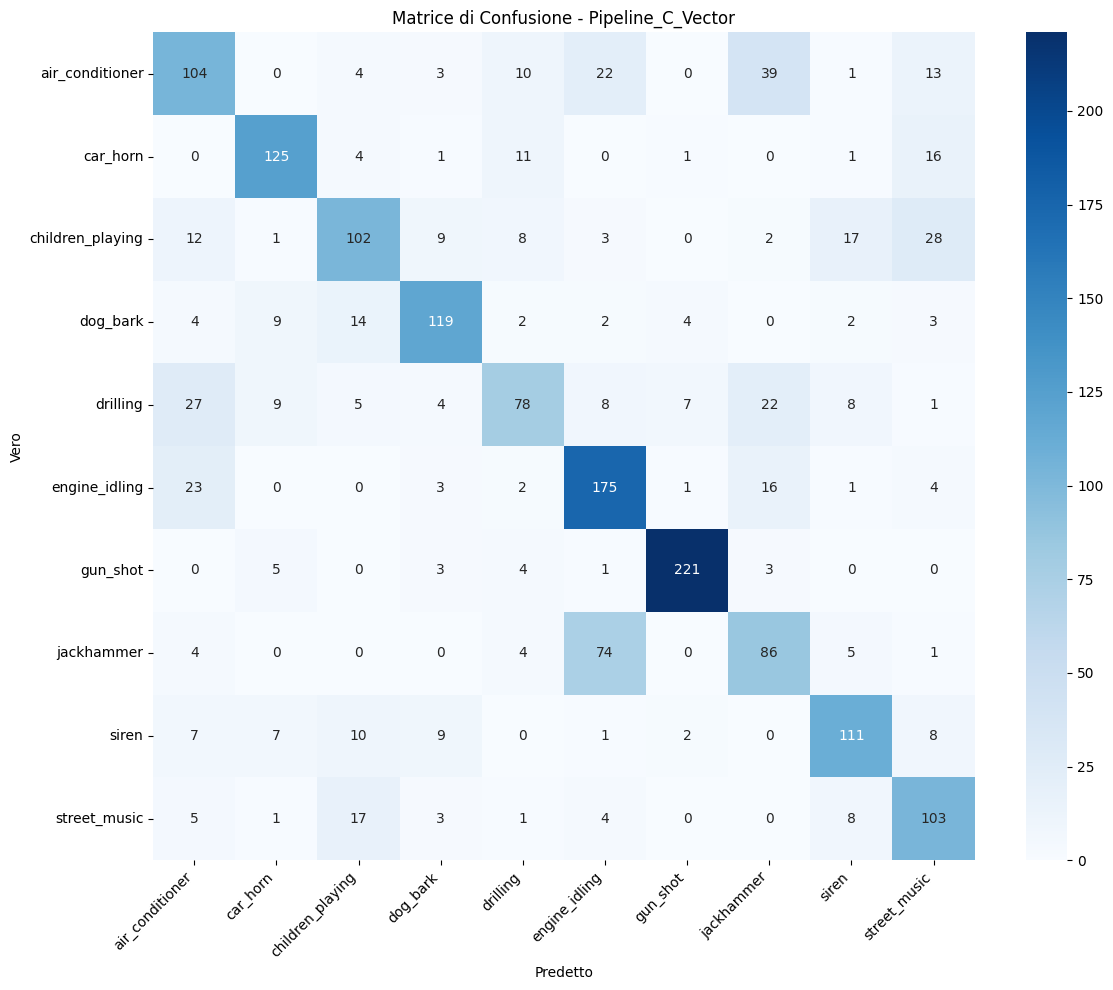


[Fase 5/5] Salvataggio del modello e dei metadati...
Modello salvato in: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/models/model_C_vector.keras


In [4]:
# --- 5. VALUTAZIONE DETTAGLIATA E SALVATAGGIO ---
print("\n[Fase 4/5] Valutazione del modello finale...")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
final_loss, final_accuracy = final_model.evaluate(X_test_final, y_test_one_hot, verbose=0)
print(f"Performance finale sul Test Set:")
print(f"  - Loss: {final_loss:.4f}")
print(f"  - Accuracy: {final_accuracy:.4f}\n")

print("Generazione del report di classificazione e della matrice di confusione...")
y_pred_probs = final_model.predict(X_test_final)
y_pred_final = np.argmax(y_pred_probs, axis=1)

print("\n--- Report di Classificazione Dettagliato ---")
print(classification_report(y_test_final, y_pred_final, target_names=class_names))

print("\n--- Matrice di Confusione ---")
conf_matrix = confusion_matrix(y_test_final, y_pred_final)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matrice di Confusione - {PIPELINE_NAME}')
plt.xlabel('Predetto')
plt.ylabel('Vero')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n[Fase 5/5] Salvataggio del modello e dei metadati...")
model_path = os.path.join(MODELS_DIR, MODEL_FILENAME)
final_model.save(model_path)
print(f"Modello salvato in: {model_path}")

metadata = {
    "pipeline_name": PIPELINE_NAME,
    "model_architecture": "1D-CNN + 2xBiGRU",
    "model_filename": MODEL_FILENAME,
    "input_shape": input_shape,
    "num_classes": num_classes,
    "class_names": class_names,
    "final_test_performance": {"accuracy": final_accuracy, "loss": final_loss}
}
# Aggiungi le metriche di CV solo se il CV è stato eseguito
if 'mean_acc_cv' in locals() and 'std_acc_cv' in locals():
    metadata["cv_performance"] = {"mean_accuracy": mean_acc_cv, "std_accuracy": std_acc_cv}

metadata_path = os.path.join(MODELS_DIR, METADATA_FILENAME)
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)